**Цель работы:** исследование методов анализа ассоциативных правил.

**Постановка задачи:**
1. Загрузить датасет из репозитория (например, kaggle.com или аналогичных платформ). Данные должны представлять собой информацию о купленных вместе товарах.
2. Привести описание данных из датасета: график вывода длин транзакций, список уникальных товаров и др. 
3. Алгоритм Apriori: выполнить анализ ассоциативных правил при помощи алгоритма Apriori с изначальными условиями в соответствии с вариантом задания. Проанализировать полученные результаты, выделив полезные и тривиальные правила, и оценив значение достоверности, лифта правил. Провести оценку влияния параметров алгоритма на получаемые правила (на количество правил и метрики).
4. Алгоритм FPG: провести анализ правил, используя алгоритм FPG. В отчете привести правила, получившиеся в результате использования данного алгоритма.
5. Алгоритмически определить минимальные значения поддержки для составления правил из 1, 2, и т.д. объектов в одном из алгоритмов.
6. Последовательно меняя параметры (значения поддержки и достоверности) одного из алгоритмов получить наборы ассоциативных правил. Сделать выводы на основе проведенных экспериментов.
7. Проанализировать получающийся в результате работы программы граф. Объяснить, какую информацию можно из него извлечь.
8. Предложить и реализовать свой способ визуализации ассоциативных правил и метрик.

**Вариант 4** <br>
Online Retail Data Set — это набор данных о транзакциях британского онлайн-ритейлера, специализирующегося на уникальных подарках для всех возрастов, за период с 01.12.2010 по 09.12.2011.

          0       1       2       3       4       5       6
0     Bread    Wine    Eggs    Meat  Cheese  Pencil  Diaper
1     Bread  Cheese    Meat  Diaper    Wine    Milk  Pencil
2    Cheese    Meat    Eggs    Milk    Wine     NaN     NaN
3    Cheese    Meat    Eggs    Milk    Wine     NaN     NaN
4      Meat  Pencil    Wine     NaN     NaN     NaN     NaN
..      ...     ...     ...     ...     ...     ...     ...
310   Bread    Eggs  Cheese     NaN     NaN     NaN     NaN
311    Meat    Milk  Pencil     NaN     NaN     NaN     NaN
312   Bread  Cheese    Eggs    Meat  Pencil  Diaper    Wine
313    Meat  Cheese     NaN     NaN     NaN     NaN     NaN
314    Eggs    Wine   Bagel   Bread    Meat     NaN     NaN

[315 rows x 7 columns]


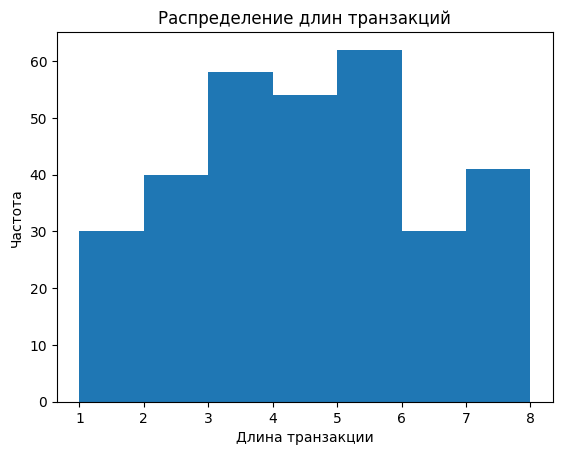

{'Wine', 'Pencil', 'Cheese', 'Bagel', 'Bread', 'Milk', 'Eggs', 'Diaper', 'Meat'}


In [12]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from mlxtend.preprocessing import TransactionEncoder
#Загрузка данных
all_data = pd.read_csv('retail_dataset.csv')
print(all_data) 
#Анализ транзакций
transaction_lengths = all_data.notnull().sum(axis=1)
plt.hist(transaction_lengths, bins=range(1, max(transaction_lengths) + 2))
plt.xlabel('Длина транзакции')
plt.ylabel('Частота')
plt.title('Распределение длин транзакций')
plt.show()
#Очистка данных
np_data = all_data.to_numpy()
np_data = [[elem for elem in row[1:] if isinstance(elem,str)] for row in np_data]
#Список уникальных товаров
unique_items = set()
for row in np_data:
    for elem in row:
        unique_items.add(elem)
print(unique_items)
te = TransactionEncoder()
te_ary = te.fit(np_data).transform(np_data)
data = pd.DataFrame(te_ary, columns=te.columns_)

In [13]:
from mlxtend.frequent_patterns import apriori, association_rules, fpgrowth
import networkx as nx

#Алгоритм Apriori
df1 = apriori(data, min_support=0.15, use_colnames = True)
print(df1)

     support            itemsets
0   0.326984             (Bagel)
1   0.269841             (Bread)
2   0.323810            (Cheese)
3   0.298413            (Diaper)
4   0.361905              (Eggs)
5   0.374603              (Meat)
6   0.453968              (Milk)
7   0.279365            (Pencil)
8   0.365079              (Wine)
9   0.158730       (Bagel, Milk)
10  0.158730      (Wine, Diaper)
11  0.215873        (Eggs, Meat)
12  0.212698        (Eggs, Milk)
13  0.180952        (Eggs, Wine)
14  0.209524        (Meat, Milk)
15  0.203175        (Meat, Wine)
16  0.168254        (Wine, Milk)
17  0.155556  (Eggs, Milk, Meat)


In [14]:
from IPython.display import display

rules = association_rules(df1, metric="confidence", min_threshold=0.4)
display(rules)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(Bagel),(Milk),0.326984,0.453968,0.158730,0.485437,1.069319,1.0,0.010290,1.061156,0.096321,0.255102,0.057632,0.417544
1,(Wine),(Diaper),0.365079,0.298413,0.158730,0.434783,1.456984,1.0,0.049786,1.241270,0.494000,0.314465,0.194373,0.483349
2,(Diaper),(Wine),0.298413,0.365079,0.158730,0.531915,1.456984,1.0,0.049786,1.356421,0.447059,0.314465,0.262766,0.483349
3,(Eggs),(Meat),0.361905,0.374603,0.215873,0.596491,1.592328,1.0,0.080302,1.549896,0.582968,0.414634,0.354796,0.586381
4,(Meat),(Eggs),0.374603,0.361905,0.215873,0.576271,1.592328,1.0,0.080302,1.505905,0.594804,0.414634,0.335947,0.586381
5,(Eggs),(Milk),0.361905,0.453968,0.212698,0.587719,1.294626,1.0,0.048405,1.324417,0.356650,0.352632,0.244951,0.528125
6,(Milk),(Eggs),0.453968,0.361905,0.212698,0.468531,1.294626,1.0,0.048405,1.200627,0.416782,0.352632,0.167102,0.528125
7,(Eggs),(Wine),0.361905,0.365079,0.180952,0.500000,1.369565,1.0,0.048828,1.269841,0.422886,0.331395,0.212500,0.497826
8,(Wine),(Eggs),0.365079,0.361905,0.180952,0.495652,1.369565,1.0,0.048828,1.265189,0.425000,0.331395,0.209604,0.497826
9,(Meat),(Milk),0.374603,0.453968,0.209524,0.559322,1.232073,1.0,0.039466,1.239072,0.301184,0.338462,0.192944,0.510430


**Полезные правила:**

№15 (Meat, Milk) -> (Eggs)<br>
Лифт: 2.051 <br>
Достоверность: 0.742<br>
Покупатели, которые берут мясо и молоко, с очень высокой вероятностью (74.2%) также купят яйца. Набор встречается в 2 раза чаще, чем покупают яйца в среднем по всем транзакциям.

№16 (Eggs, Milk) -> (Meat)<br>
Лифт: 1.952<br>
Достоверность: 0.731<br>
Почти зеркальное правило к предыдущему. Покупка яиц и молока хорошо предсказывает покупку мяса. Это значит, что компания может разместить молоко, яйца и мясо в одной зоне.

№1 (Diaper) -> (Wine) и №2 (Wine) -> (Diaper)<br>
Лифт: 1.457<br>
Достоверность: 0.53 / 0.43<br>
Покупка подгузников ассоциирована с покупкой вина. Это может быть связано с поведением родителей, которые покупают вино для себя. Значит, стоит рассмотреть возможность размещения подгузников рядом с вином или создания какой-то акции.

**Тривиальные правила:**

№11 (Meat) -> (Wine) и №12 (Wine) -> (Meat)<br>
Лифт: 1.486<br>
Достоверность: 0.54 / 0.56<br>
Мясо и вино — классическое гастрономическое сочетание, что и подтверждается данными.

№3 (Meat) -> (Eggs) и №4 (Eggs) -> (Meat)<br>
Лифт: 1.592<br>
Достоверность: 0.58<br>
Связь мяса и яиц очевидна - это базовые продукты для готовки. Правило лишь подтверждает известную информацию.

In [15]:
df1 = fpgrowth(data, min_support=0.15, use_colnames = True)
print(df1)

     support            itemsets
0   0.374603              (Meat)
1   0.365079              (Wine)
2   0.361905              (Eggs)
3   0.323810            (Cheese)
4   0.298413            (Diaper)
5   0.279365            (Pencil)
6   0.453968              (Milk)
7   0.326984             (Bagel)
8   0.269841             (Bread)
9   0.209524        (Meat, Milk)
10  0.203175        (Meat, Wine)
11  0.168254        (Wine, Milk)
12  0.215873        (Eggs, Meat)
13  0.180952        (Eggs, Wine)
14  0.212698        (Eggs, Milk)
15  0.155556  (Eggs, Milk, Meat)
16  0.158730      (Wine, Diaper)
17  0.158730       (Bagel, Milk)


In [16]:
rules = association_rules(df1, metric="confidence", min_threshold=0.4)
display(rules)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(Meat),(Milk),0.374603,0.453968,0.209524,0.559322,1.232073,1.0,0.039466,1.239072,0.301184,0.338462,0.192944,0.510430
1,(Milk),(Meat),0.453968,0.374603,0.209524,0.461538,1.232073,1.0,0.039466,1.161451,0.344961,0.338462,0.139008,0.510430
2,(Meat),(Wine),0.374603,0.365079,0.203175,0.542373,1.485630,1.0,0.066415,1.387419,0.522684,0.378698,0.279237,0.549447
3,(Wine),(Meat),0.365079,0.374603,0.203175,0.556522,1.485630,1.0,0.066415,1.410209,0.514844,0.378698,0.290885,0.549447
4,(Wine),(Milk),0.365079,0.453968,0.168254,0.460870,1.015202,1.0,0.002520,1.012801,0.023585,0.258537,0.012639,0.415749
5,(Eggs),(Meat),0.361905,0.374603,0.215873,0.596491,1.592328,1.0,0.080302,1.549896,0.582968,0.414634,0.354796,0.586381
6,(Meat),(Eggs),0.374603,0.361905,0.215873,0.576271,1.592328,1.0,0.080302,1.505905,0.594804,0.414634,0.335947,0.586381
7,(Eggs),(Wine),0.361905,0.365079,0.180952,0.500000,1.369565,1.0,0.048828,1.269841,0.422886,0.331395,0.212500,0.497826
8,(Wine),(Eggs),0.365079,0.361905,0.180952,0.495652,1.369565,1.0,0.048828,1.265189,0.425000,0.331395,0.209604,0.497826
9,(Eggs),(Milk),0.361905,0.453968,0.212698,0.587719,1.294626,1.0,0.048405,1.324417,0.356650,0.352632,0.244951,0.528125


In [17]:
# Подбор минимальной поддержки для наборов
support_values = [i/100 for i in range(50, 0, -1)]
length_results = {i: None for i in range(1, 8)}

for support in support_values:
    frequent_itemsets = fpgrowth(data, min_support=support, use_colnames=True)
    
    if not frequent_itemsets.empty:
        frequent_itemsets['length'] = frequent_itemsets['itemsets'].apply(len)

        for length in range(1, 8):
            if length == frequent_itemsets['length'].max():
                length_results[length] = support

results_df = pd.DataFrame({
    'Количество объектов': list(length_results.keys()),
    'Поддержка': [f"{support:.2f}" if support is not None else "не найдено" 
                   for support in length_results.values()]
})

print("Минимальные поддержки по длинам наборов:")
print(results_df.to_string(index=False))

Минимальные поддержки по длинам наборов:
 Количество объектов  Поддержка
                   1       0.22
                   2       0.16
                   3       0.08
                   4       0.03
                   5       0.02
                   6       0.01
                   7 не найдено


Выводы по результатам изменений параметров:
1. Чем меньше значение поддержки, тем больше появляется случайных зависимостей и шума. При высоком значении, напротив, могут потеряться ценные взаимосвязи. Нужно искать баланс между избыточностью и многообразием. 
2. Чем выше значение достоверности, тем более очевидными становятся найденные правила. Но при малом значении правила становятся слишком бесполезными. Необходимо получить такое значение, которое сохраняет нетривиальные, значимые правила.

    support itemsets
6  0.453968     Milk
0  0.374603     Meat
1  0.365079     Wine
2  0.361905     Eggs
7  0.326984    Bagel
3  0.323810   Cheese
4  0.298413   Diaper
5  0.279365   Pencil
8  0.269841    Bread


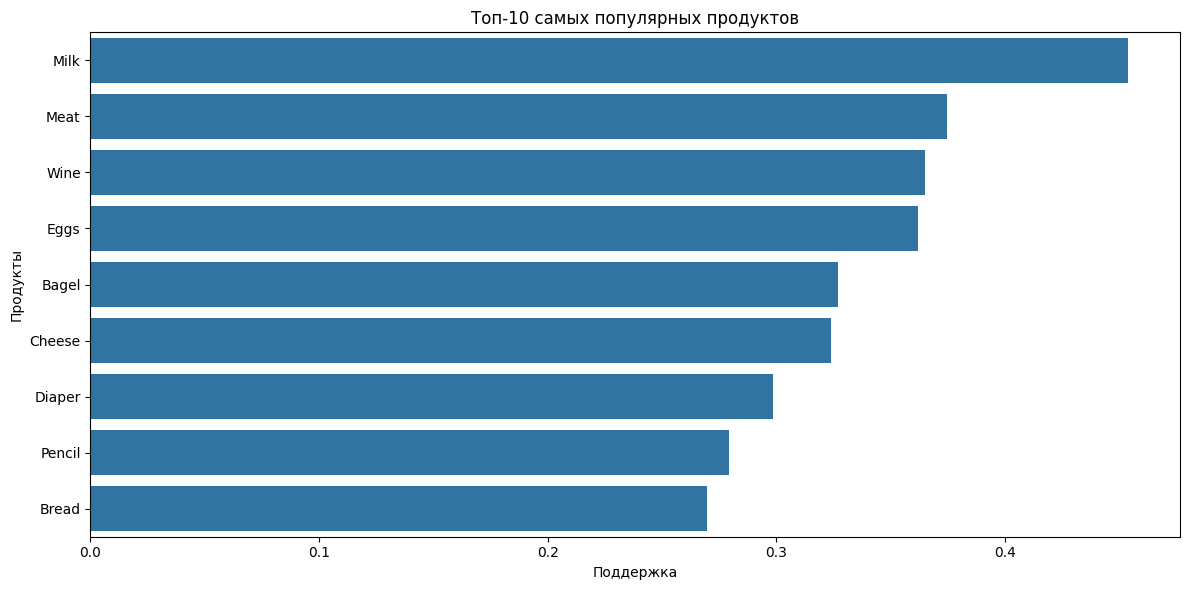

In [18]:
df1['itemsets'] = df1['itemsets'].apply(lambda x: ', '.join(list(x))) 
top_products = df1.sort_values(by='support', ascending=False).head(9)
print(top_products)
plt.figure(figsize=(12, 6))
sns.barplot(x='support', y='itemsets', data=top_products)
plt.title('Топ-10 самых популярных продуктов')
plt.xlabel('Поддержка')
plt.ylabel('Продукты')
plt.tight_layout()
plt.show()
rules['antecedents'] = rules['antecedents'].apply(lambda x: ', '.join(list(x))) 
rules['consequents'] = rules['consequents'].apply(lambda x: ', '.join(list(x))) 

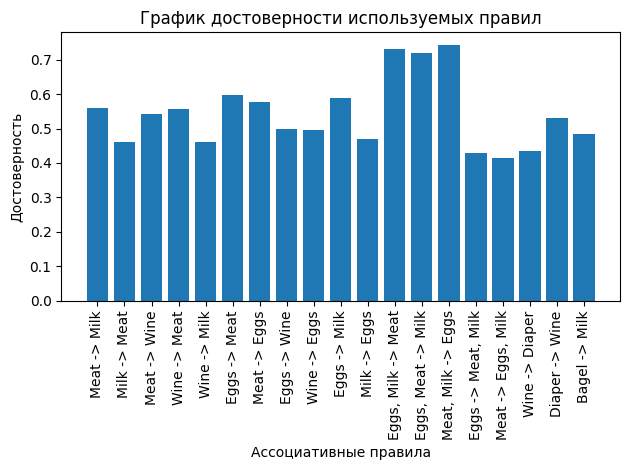

In [19]:
#График достоверности используемых правил
products_1 = rules["antecedents"].tolist()
products_2 = rules["consequents"].tolist()
confidence = rules["confidence"].tolist()
rules_labels = [f"{product1} -> {product2}" for product1, product2 in zip(products_1, products_2)]
plt.bar(rules_labels, confidence)
plt.xlabel("Ассоциативные правила")
plt.ylabel("Достоверность")
plt.title("График достоверности используемых правил")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

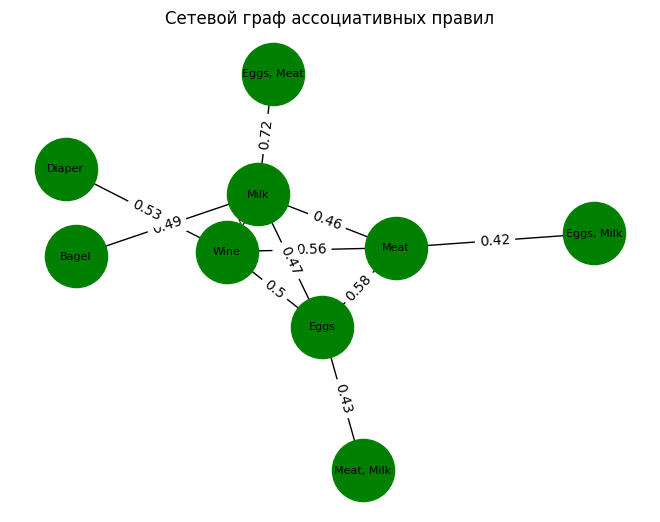

In [20]:
#Визуализация ассоциативных правил в виде графа
G = nx.Graph()
for product in rules["antecedents"]:
    G.add_node(product)
for product in rules["consequents"]:
    G.add_node(product)
for index, row in rules.iterrows():
    G.add_edge(row['antecedents'], row['consequents'], weight=row['confidence'])
pos = nx.spring_layout(G)
nx.draw(G, pos, with_labels=True, node_size=2000, node_color='green', font_size=8)
edge_labels = nx.get_edge_attributes(G, 'weight')

# Округляем значения до 2 знаков после запятой
edge_labels_rounded = {k: round(v, 2) for k, v in edge_labels.items()}

nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels_rounded)
plt.title('Сетевой граф ассоциативных правил')
plt.show()

Граф, полученный в результате работы программы, показывает взаимосвязи между самыми популярными товарами и силу этих связей через достоверность ассоциативных правил.

Для визуализации ассоциативных правил можно улучшить сетевой граф, изменяя размеры узлов в зависисмости от общего количества связей, а толщину и яркость ребер менять в зависимости от значения достоверности правила. <br>
Для визуализации метрик ассоциативных правил можно использовать тепловую карту, так будет проще сравнивать значения между собой.

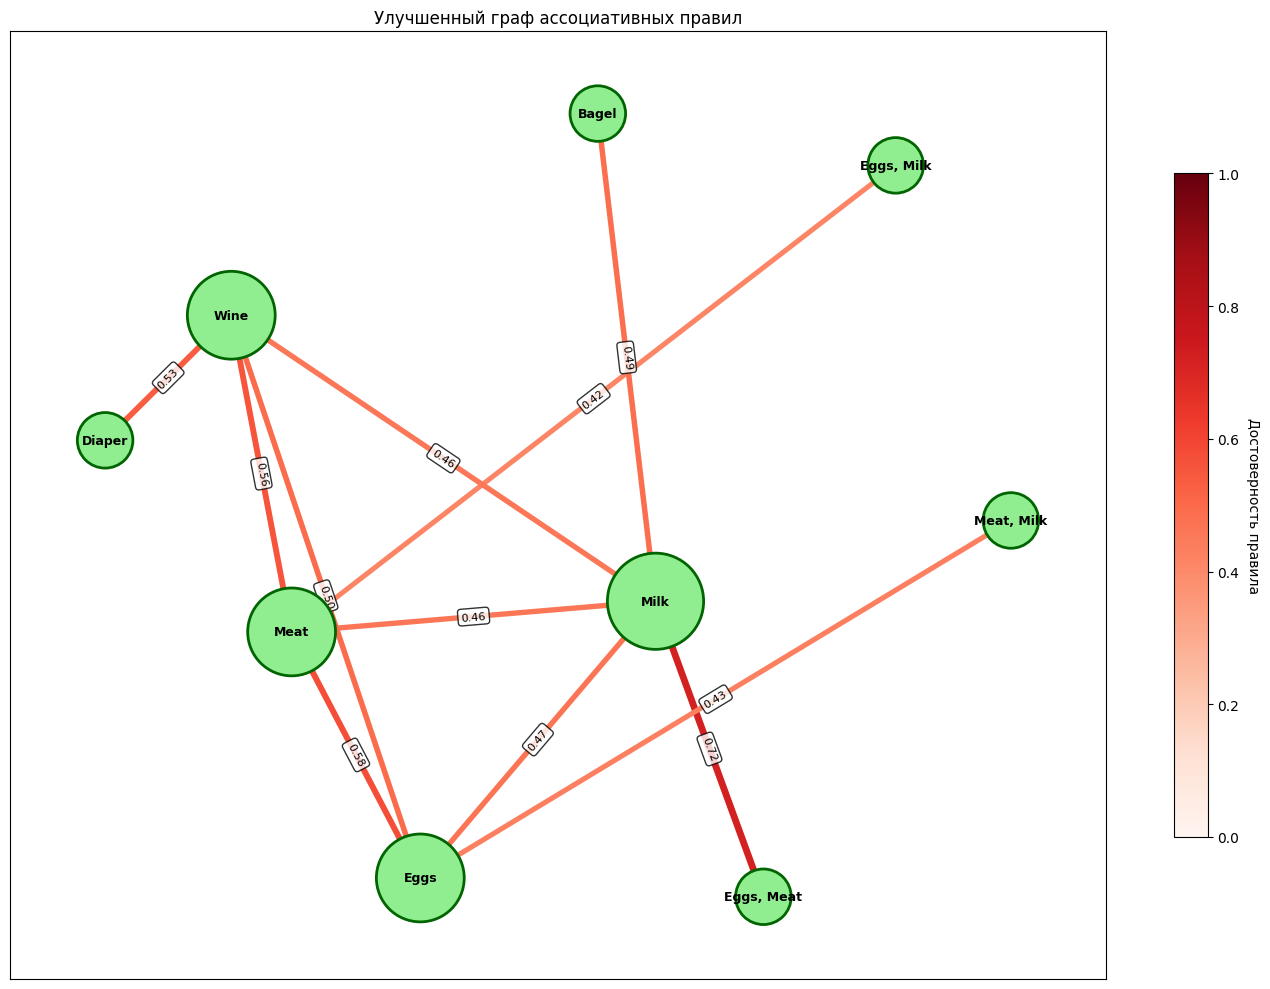

In [21]:
# Улучшенная визуализация ассоциативных правил в виде графа
plt.figure(figsize=(14, 10))
G = nx.Graph()

for product in rules["antecedents"]:
    G.add_node(product)
for product in rules["consequents"]:
    G.add_node(product)
for index, row in rules.iterrows():
    G.add_edge(row['antecedents'], row['consequents'], 
               weight=row['confidence'],
               confidence=row['confidence'])

pos = nx.spring_layout(G, k=2, iterations=50)

node_sizes = []
for node in G.nodes():
    degree = G.degree(node)
    size = 800 + degree * 800
    node_sizes.append(size)

edge_colors = []
edge_widths = []
for u, v, data in G.edges(data=True):
    confidence = data['confidence']
    edge_colors.append(plt.cm.Reds(confidence))
    edge_widths.append(2 + confidence * 4)

nx.draw_networkx_nodes(G, pos, 
                      node_size=node_sizes,
                      node_color='lightgreen',
                      edgecolors='darkgreen',
                      linewidths=2)

edges = nx.draw_networkx_edges(G, pos,
                              edge_color=edge_colors,
                              width=edge_widths,
                              edge_cmap=plt.cm.Reds)

# Подписи узлов
nx.draw_networkx_labels(G, pos, 
                       font_size=9,
                       font_weight='bold',
                       font_family='sans-serif')

# Подписи ребер (достоверность)
edge_labels = {(u, v): f"{data['confidence']:.2f}" 
               for u, v, data in G.edges(data=True)}
nx.draw_networkx_edge_labels(G, pos, 
                           edge_labels=edge_labels,
                           font_size=8,
                           bbox=dict(boxstyle="round,pad=0.3", 
                                   facecolor="white", 
                                   alpha=0.8))

plt.title('Улучшенный граф ассоциативных правил')

# Добавляем цветовую шкалу для ребер
sm = plt.cm.ScalarMappable(cmap=plt.cm.Reds, 
                          norm=plt.Normalize(vmin=0, vmax=1))
sm.set_array([])
cbar = plt.colorbar(sm, ax=plt.gca(), shrink=0.7)
cbar.set_label('Достоверность правила', rotation=270, labelpad=15)

plt.tight_layout()
plt.show()

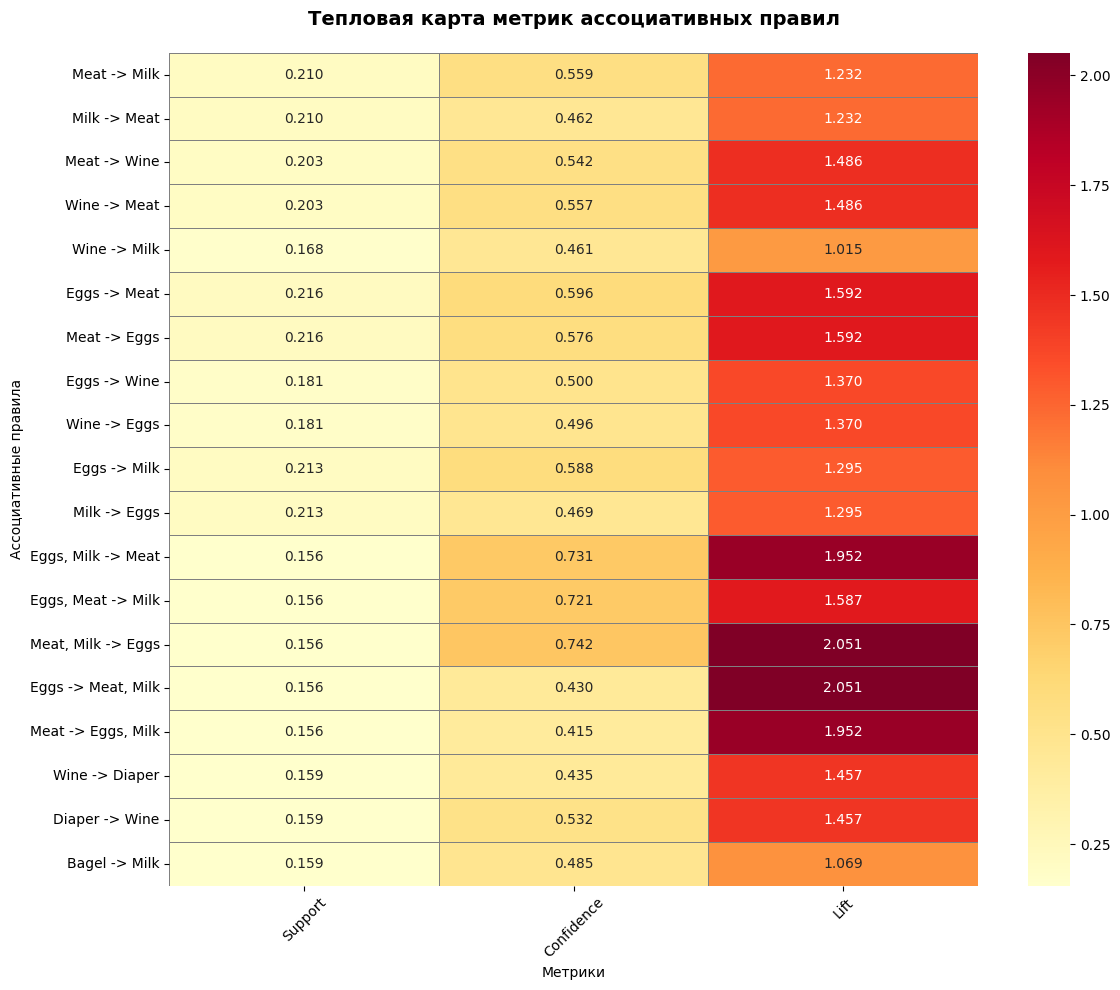

In [22]:
# Тепловая карта метрик
def create_simple_heatmap(rules):

    rules_list = []
    for _, rule in rules.iterrows():
        rule_label = f"{rule['antecedents']} -> {rule['consequents']}"
        rules_list.append({
            'Rule': rule_label,
            'Support': rule['support'],
            'Confidence': rule['confidence'], 
            'Lift': rule['lift']
        })

    heatmap_df = pd.DataFrame(rules_list)
    heatmap_df = heatmap_df.set_index('Rule')

    plt.figure(figsize=(12, 10))
    
    sns.heatmap(heatmap_df, 
                annot=heatmap_df.round(3),
                fmt='.3f',
                cmap='YlOrRd',
                linewidths=0.5,
                linecolor='gray')
    
    plt.title(f'Тепловая карта метрик ассоциативных правил', 
              fontsize=14, fontweight='bold', pad=20)
    plt.xlabel('Метрики')
    plt.ylabel('Ассоциативные правила')
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)
    plt.tight_layout()
    
    return heatmap_df

heatmap_data = create_simple_heatmap(rules)
plt.show()